In [5]:
from resram_core import load_input, resram_data, param_init, raman_residual, run_save
from tqdm import tqdm
import time
from datetime import datetime
import numpy as np
import lmfit

import resram_core
# resram_core.HAS_RUST = False  # Disable Rust implementation for benchmarking

No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/


/home/likun/ResRam_Jupyter/resram_core.py:923: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig_raman.show()
/home/likun/ResRam_Jupyter/resram_core.py:936: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/home/likun/ResRam_Jupyter/resram_core.py:928: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 6))
/home/likun/ResRam_Jupyter/resram_core.py:989: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig_profs.show()


no experimental fluorescence data
Elapsed time: 0.2687995433807373 seconds


/home/likun/ResRam_Jupyter/resram_core.py:1037: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig_absfl.show()


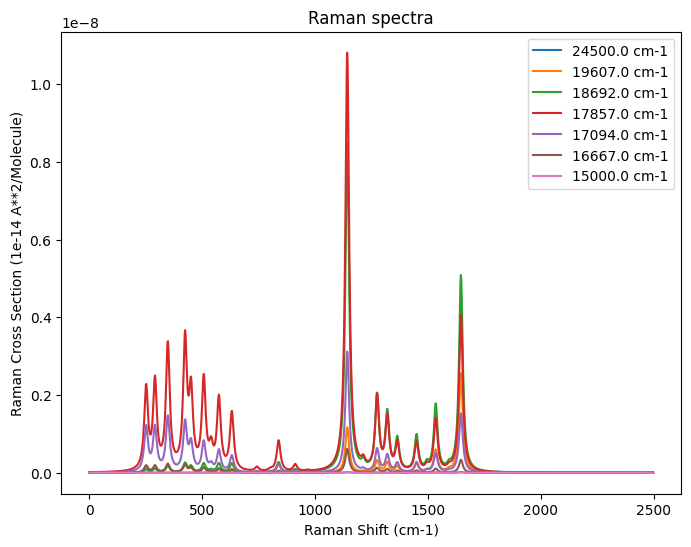

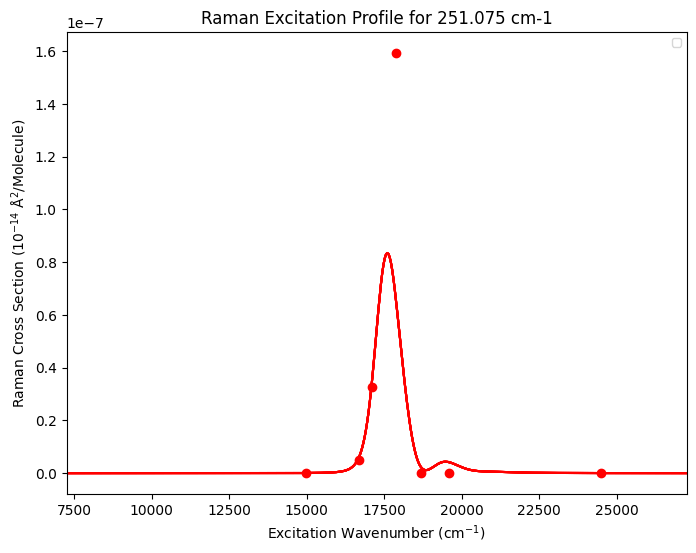

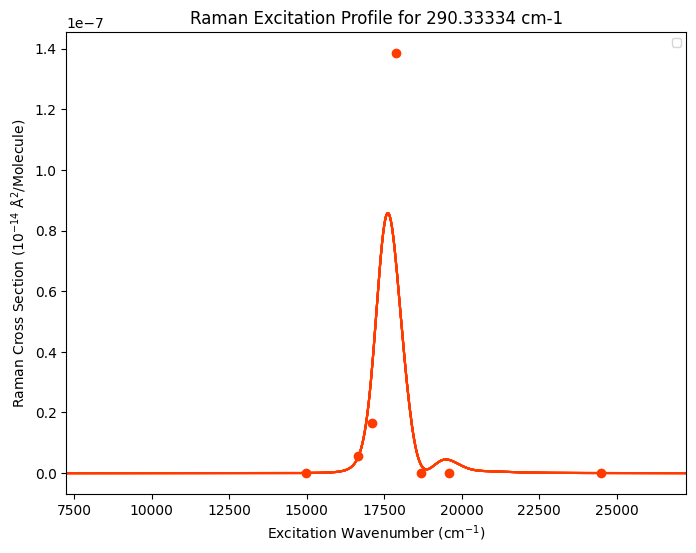

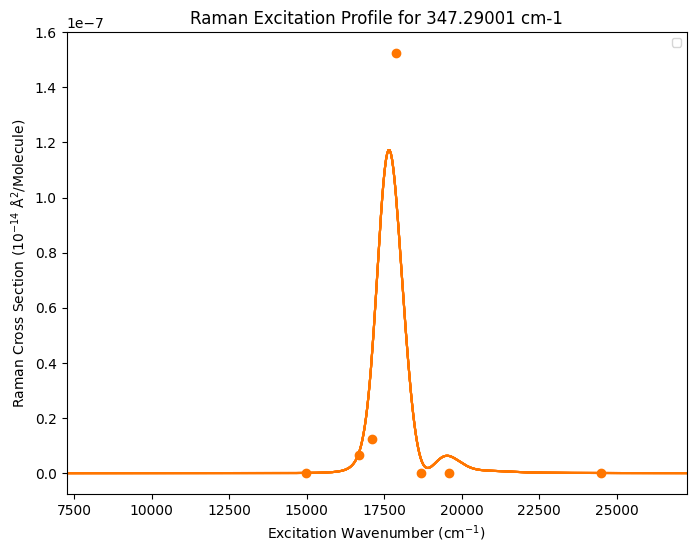

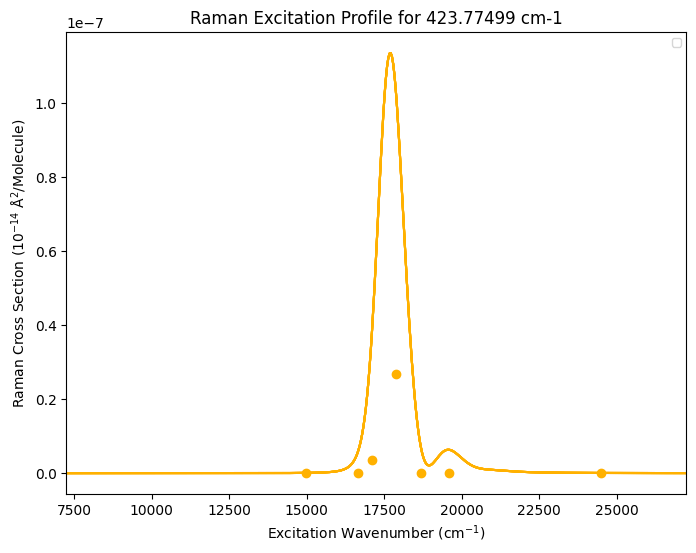

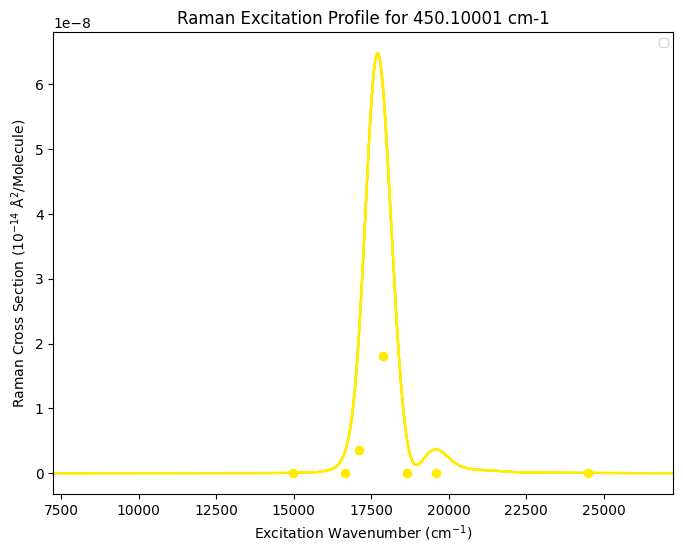

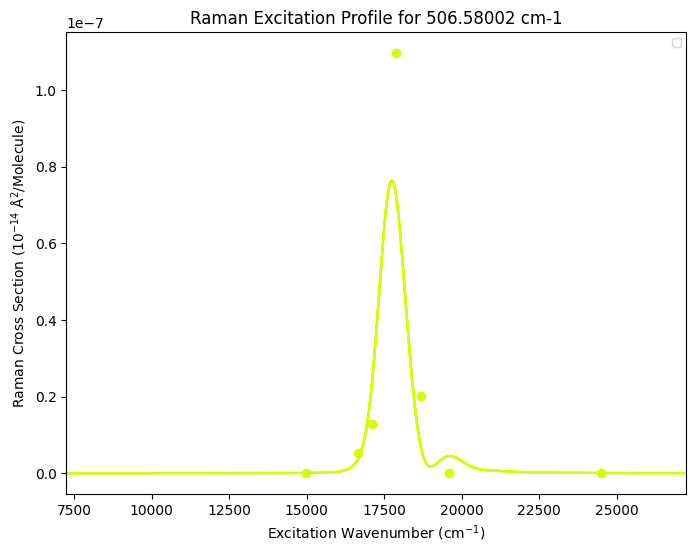

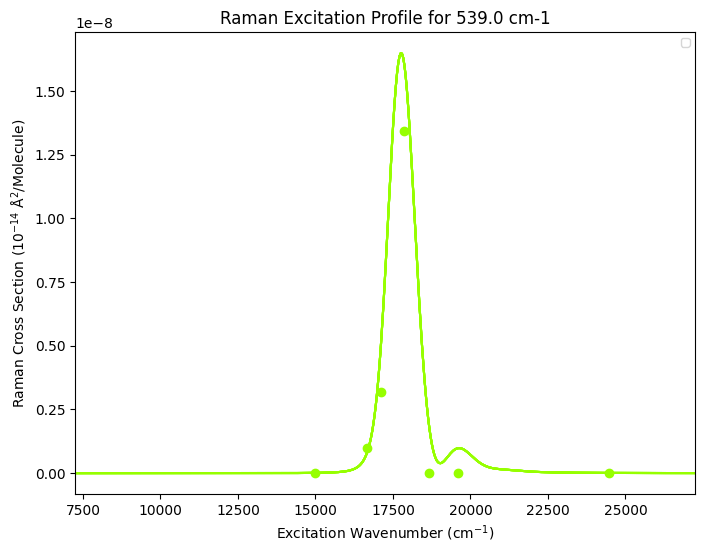

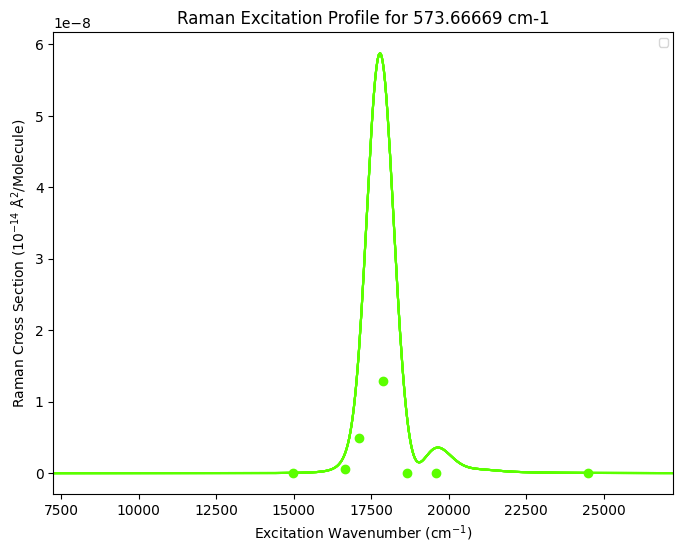

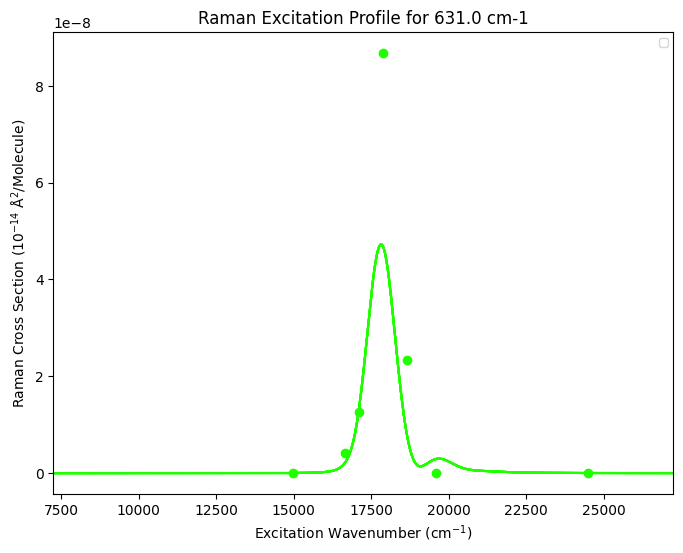

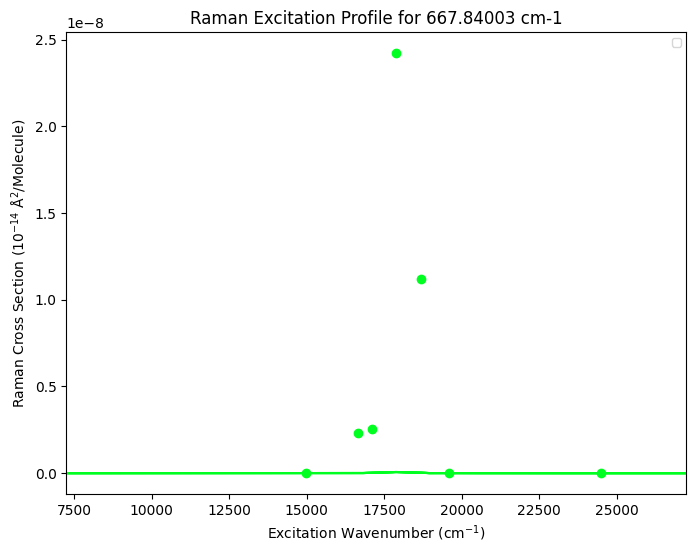

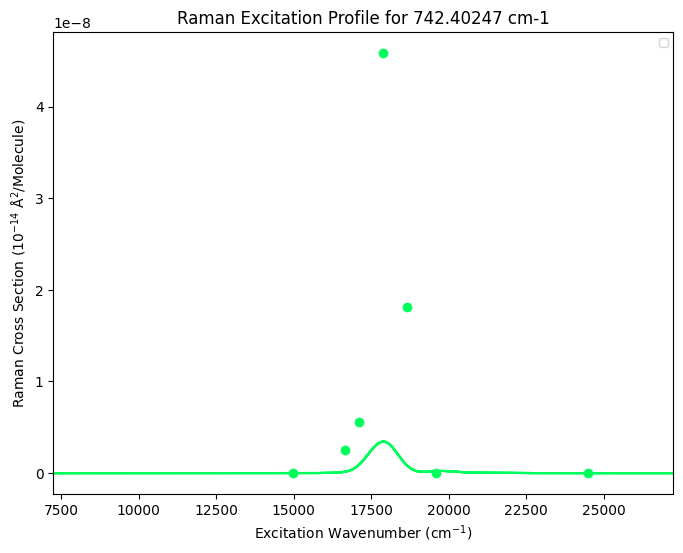

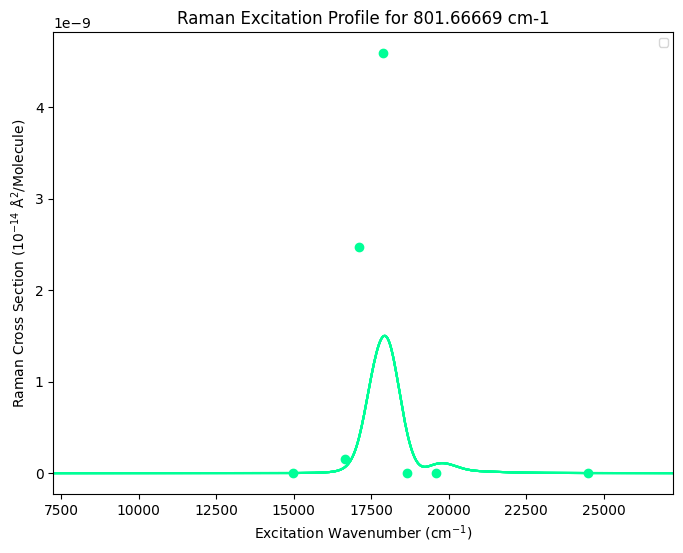

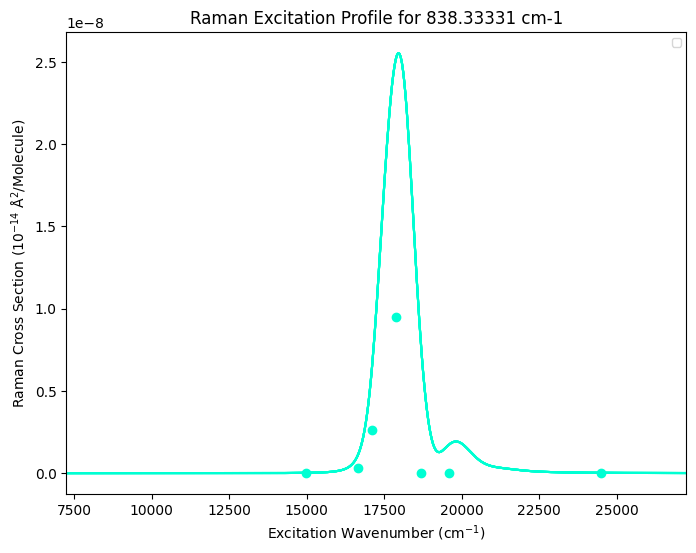

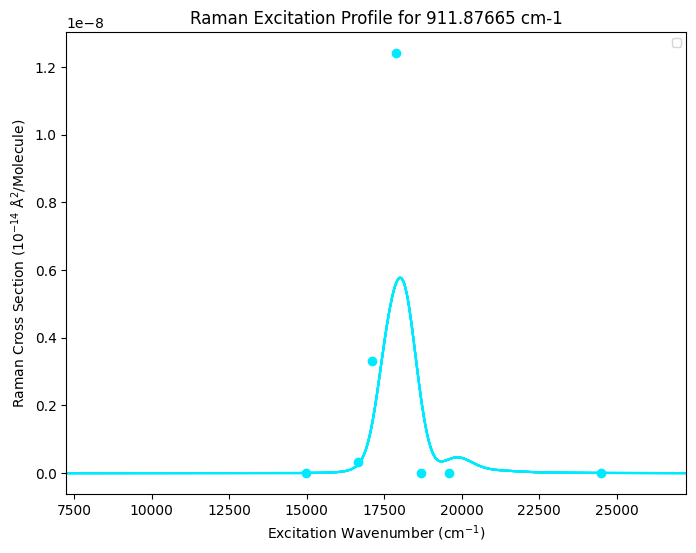

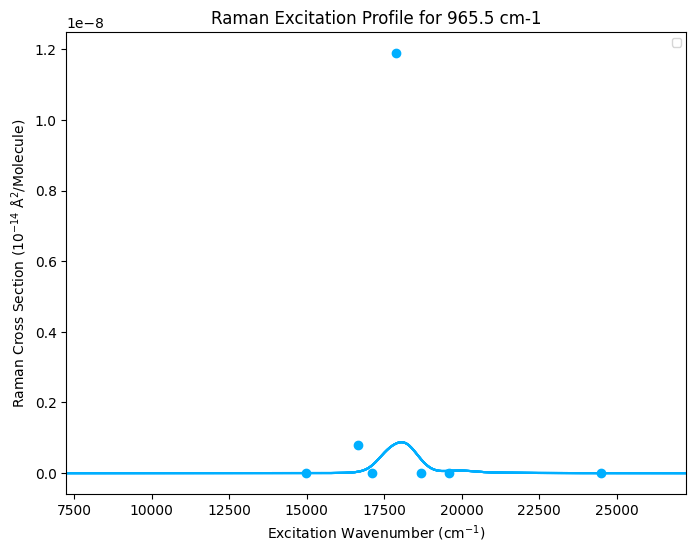

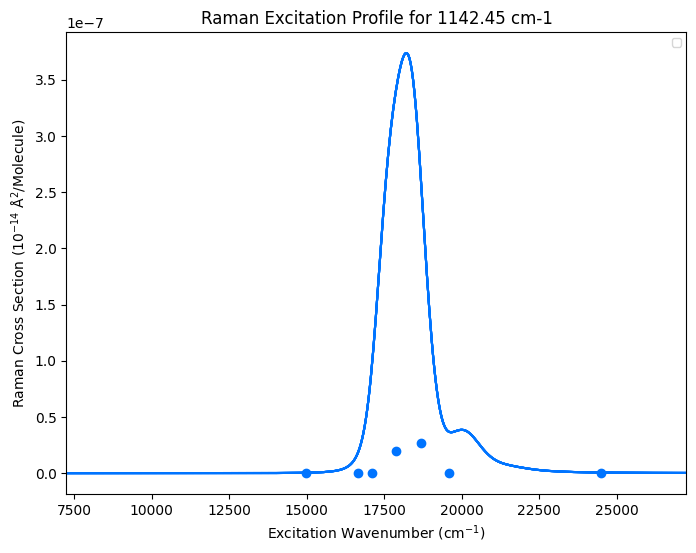

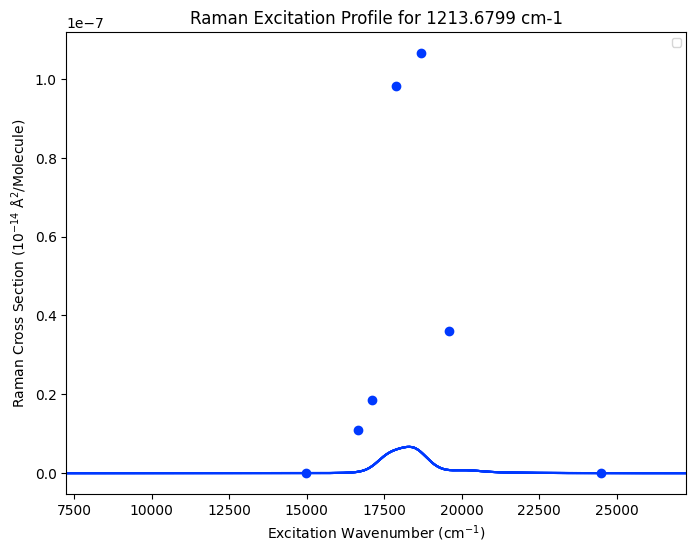

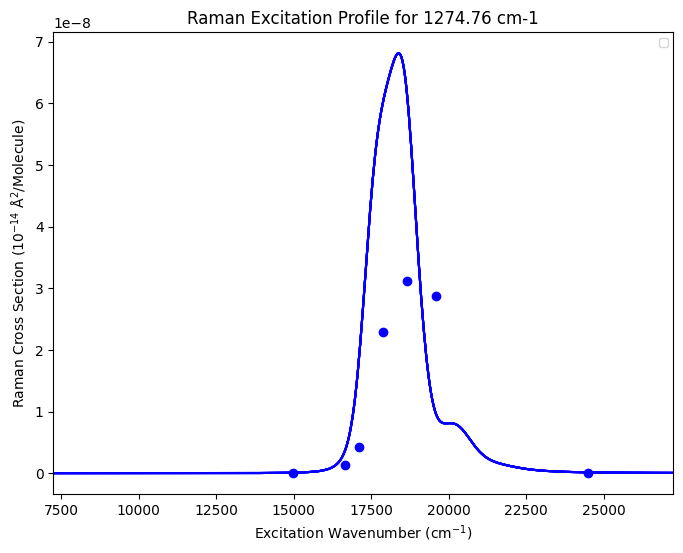

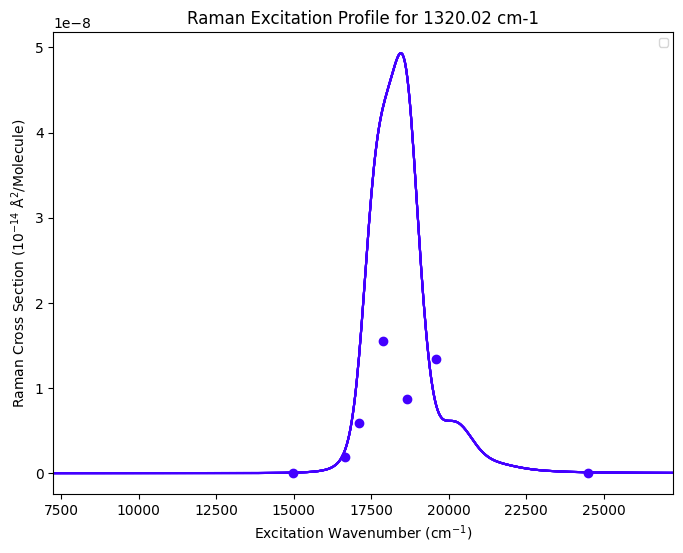

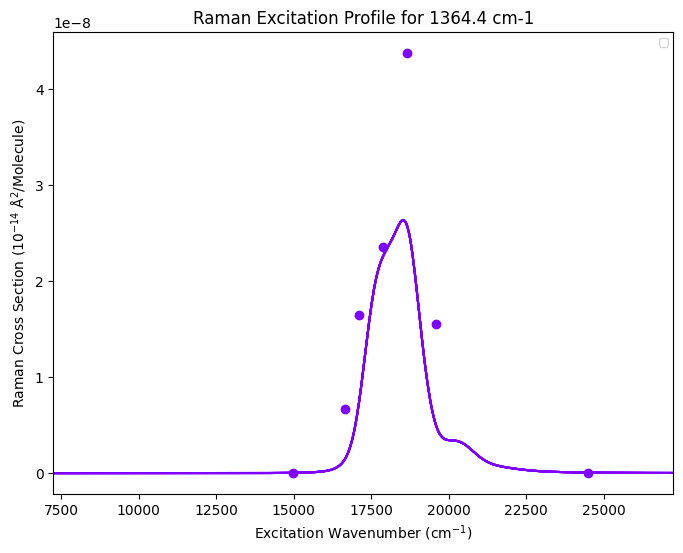

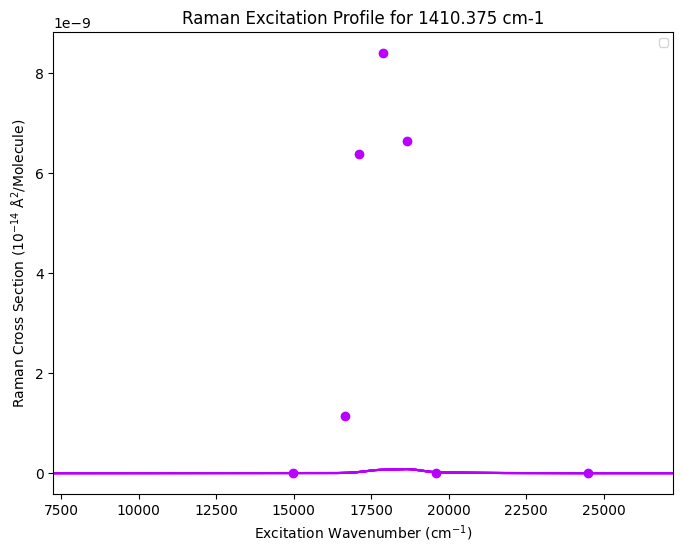

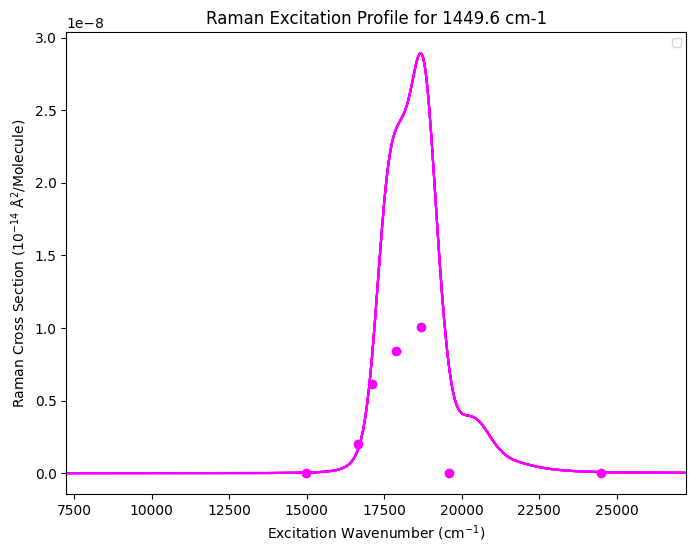

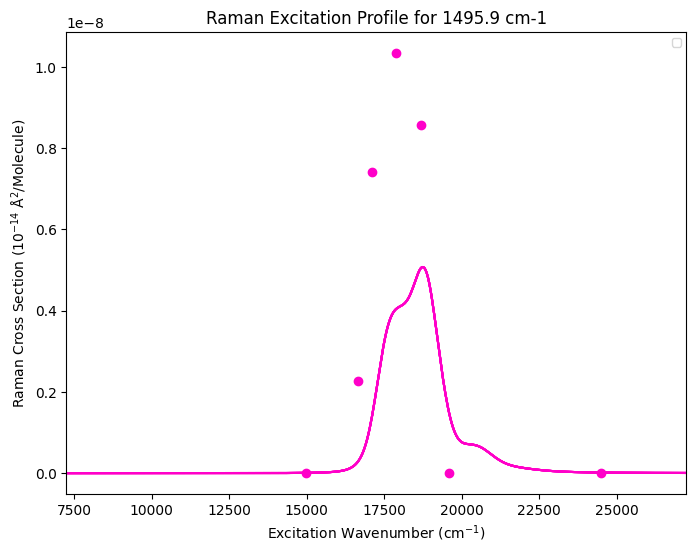

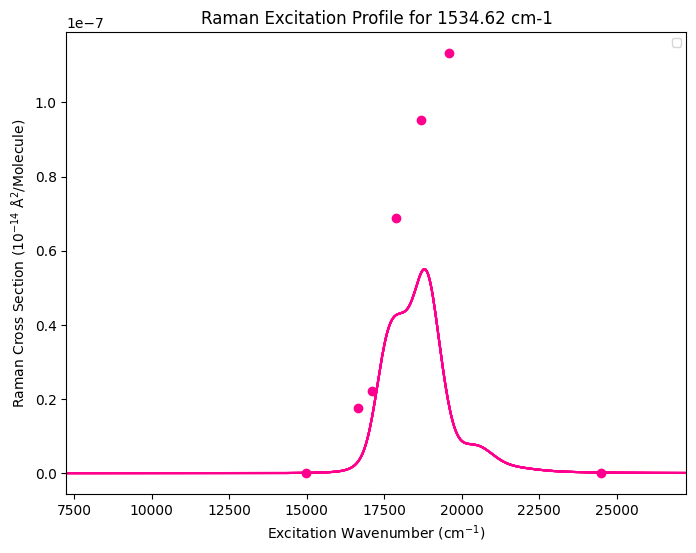

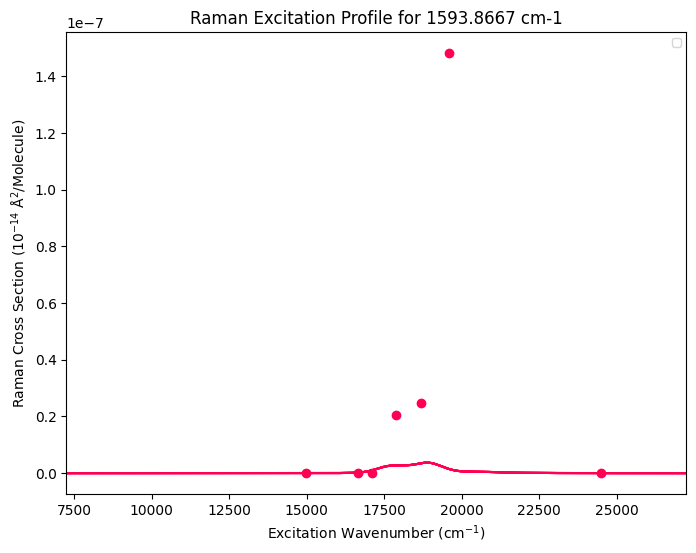

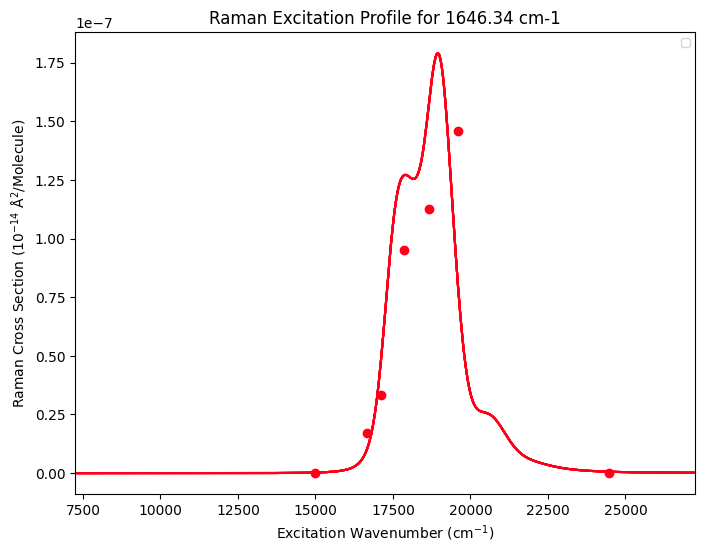

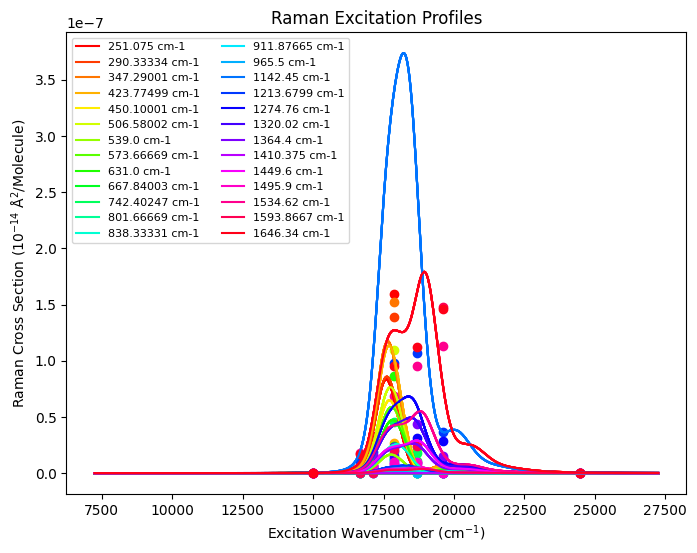

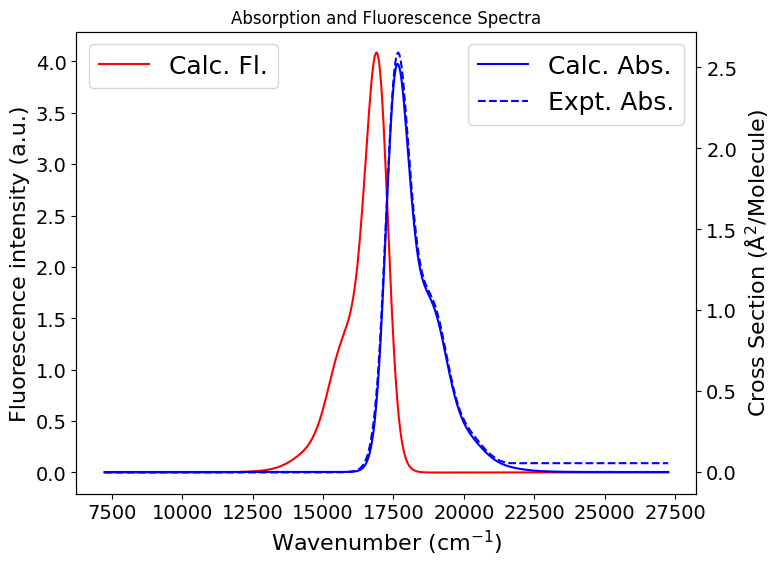

In [2]:
# Count time for loading data and simulation
start_time = time.time()
for i in range(1):
    data = resram_data() #load input data from current directory and calculate cross sections
data.plot()
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

In [3]:
start_time = time.time()
for i in range(100):
    fit_obj = load_input()
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
print(fit_obj.rp)

No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimental fluorescence spectrum found in directory/
No experimenta

In [4]:
# Initialize the 'fit_obj' object of class 'load_input'.
# Load from input files in root dir or specified dir.
fit_obj = load_input() 

fit_switch = np.ones(len(fit_obj.delta)+7)
fit_switch[len(fit_obj.delta)] = 1  # fit gamma?
fit_switch[len(fit_obj.delta)+1] = 1  # fit M?
fit_switch[len(fit_obj.delta)+2] = 1  # fit theta?
fit_switch[len(fit_obj.delta)+3] = 0  # fit kappa? We assume the slow-modulation limit, realistic for a polar solute in a polar solvent, with𝜅 = 0.1 so that the resulting lineshapes will be nearly Gaussian' in Zak's dissertation
fit_switch[len(fit_obj.delta)+5] = 0  # fit E0? 

params_lmfit = param_init(fit_switch, fit_obj)   # Initialize parameters for fitting

for name in params_lmfit.keys():
    print(params_lmfit[name])

# Initial call to populate fit_obj attributes
raman_residual(params_lmfit, fit_obj)
print(f"Initial correlation: {fit_obj.correlation}")

fit_kws = dict(tol=1e-10)    # Set fitting tolerance
max_nfev = 10000000    # Set maximum number of function evaluations

# Initialize tqdm progress bar for fitting process
with tqdm(total=max_nfev, desc="Fitting progress") as pbar:
    def update_progress(params, iteration, resid, *args, **kwargs):
        pbar.update(1)
        try:
            pbar.set_description(
                f"Iteration {iteration}, Loss: {resid[0]:.6f}, Abs_corr: {fit_obj.correlation:.6f}")
        except Exception:
            pass

    # Perform the fitting using lmfit.minimize function
    result = lmfit.minimize(raman_residual, params_lmfit, args=(fit_obj,), method='cobyla', **fit_kws,
                            max_nfev=max_nfev, iter_cb=update_progress)

print(lmfit.fit_report(result))

current_time_str = datetime.now().strftime("%Y%m%d_%H-%M-%S") 
output = run_save(fit_obj, current_time_str)  # save all parameters and results to a new folder

# Save history lists
np.savetxt(current_time_str+"_data/corr_list.dat", fit_obj.correlation_list)
np.savetxt(current_time_str+"_data/sigma_list.dat", fit_obj.sigma_list)
np.savetxt(current_time_str+"_data/loss_list.dat", fit_obj.loss_list)

print(f"Fitting completed. Results saved in {current_time_str}_data/")


No experimental fluorescence spectrum found in directory/
<Parameter 'delta0', value=np.float64(0.5481236158790151), bounds=[0.0:1.0]>
<Parameter 'delta1', value=np.float64(0.5044680555739689), bounds=[0.0:1.0]>
<Parameter 'delta2', value=np.float64(0.5232363067443214), bounds=[0.0:1.0]>
<Parameter 'delta3', value=np.float64(0.45170652386512095), bounds=[0.0:1.0]>
<Parameter 'delta4', value=np.float64(0.32837366600542084), bounds=[0.0:1.0]>
<Parameter 'delta5', value=np.float64(0.3315204881135949), bounds=[0.0:1.0]>
<Parameter 'delta6', value=np.float64(0.1484010055010908), bounds=[0.0:1.0]>
<Parameter 'delta7', value=np.float64(0.2704527881284654), bounds=[0.0:1.0]>
<Parameter 'delta8', value=np.float64(0.23054246384024535), bounds=[0.0:1.0]>
<Parameter 'delta9', value=np.float64(0.008250598213304927), bounds=[0.0:1.0]>
<Parameter 'delta10', value=np.float64(0.05774085602025658), bounds=[0.0:1.0]>
<Parameter 'delta11', value=np.float64(0.037102218497668704), bounds=[0.0:1.0]>
<Paramet

Iteration 8, Loss: 0.214358, Abs_corr: 0.992855:   0%|          | 8/10000000 [00:00<56:00:08, 49.60it/s]

Rust optimization step: Loss = 0.02819354798053673 Sigma = 2.753350474822078e-06 Correlation = 0.9990603068456646
Rust optimization step: Loss = 0.18373608062076197 Sigma = 2.2362356964087406e-06 Correlation = 0.9938755385204978
Rust optimization step: Loss = 0.23090283710754034 Sigma = 2.253754437308657e-06 Correlation = 0.9923033138882299
Rust optimization step: Loss = 0.2978653397166098 Sigma = 2.241373330248776e-06 Correlation = 0.990071230055224
Rust optimization step: Loss = 0.3880861630247531 Sigma = 2.6942543304026125e-06 Correlation = 0.9870638843743192
Rust optimization step: Loss = 0.3536204820476921 Sigma = 2.616595099776219e-06 Correlation = 0.9882127378182469
Rust optimization step: Loss = 0.41414630056232027 Sigma = 2.284921406538505e-06 Correlation = 0.9861951994786362
Rust optimization step: Loss = 0.2143580682459091 Sigma = 2.526825867568739e-06 Correlation = 0.9928548152859986
Rust optimization step: Loss = 0.40810471482486027 Sigma = 2.7453373148743454e-06 Correlati

Iteration 10, Loss: 0.393457, Abs_corr: 0.986885:   0%|          | 11/10000000 [00:00<56:18:37, 49.33it/s]

Rust optimization step: Loss = 0.3934573607125304 Sigma = 2.363114988310728e-06 Correlation = 0.9868848334134153
Rust optimization step: Loss = 0.04906766594549305 Sigma = 2.521948957997075e-06 Correlation = 0.9983644952001155


...

Iteration 1398, Loss: 0.027470, Abs_corr: 0.999084:   0%|          | 1398/10000000 [00:29<59:13:16, 46.90it/s]

Rust optimization step: Loss = 0.027470439594423152 Sigma = 2.4862238196692637e-06 Correlation = 0.9990844015543132
Rust optimization step: Loss = 0.02747043885431934 Sigma = 2.486282583499231e-06 Correlation = 0.9990844015809421
Rust optimization step: Loss = 0.027470433321719986 Sigma = 2.4862593171344897e-06 Correlation = 0.9990844017645866
Rust optimization step: Loss = 0.027470434356300755 Sigma = 2.4863840257235842e-06 Correlation = 0.9990844017342575
Rust optimization step: Loss = 0.027470427020814318 Sigma = 2.486297024431504e-06 Correlation = 0.9990844019758737
Rust optimization step: Loss = 0.027470442405651437 Sigma = 2.48652879275239e-06 Correlation = 0.9990844014707714
Rust optimization step: Loss = 0.02747043508467266 Sigma = 2.4863282681993673e-06 Correlation = 0.9990844017081199
Rust optimization step: Loss = 0.027470412026490205 Sigma = 2.4862696713159984e-06 Correlation = 0.9990844024747727
Rust optimization step: Loss = 0.027470405444748894 Sigma = 2.4862024722426712

Iteration 1407, Loss: 0.027470, Abs_corr: 0.999084:   0%|          | 1407/10000000 [00:29<59:05:31, 47.00it/s]


Rust optimization step: Loss = 0.027470394936172867 Sigma = 2.486128815812789e-06 Correlation = 0.9990844030397548
Rust optimization step: Loss = 0.027470405102044345 Sigma = 2.486043990330427e-06 Correlation = 0.9990844026980649
Rust optimization step: Loss = 0.027470399533323243 Sigma = 2.486143791549047e-06 Correlation = 0.9990844028870156
Rust optimization step: Loss = 0.02747038133491722 Sigma = 2.4860564182000106e-06 Correlation = 0.9990844034907167
Rust optimization step: Loss = 0.02747037123748649 Sigma = 2.4860705990171405e-06 Correlation = 0.9990844038277704
Rust optimization step: Loss = 0.027470354298693003 Sigma = 2.4861143508999348e-06 Correlation = 0.9990844043938553
Rust optimization step: Loss = 0.02747035062630956 Sigma = 2.486225347734414e-06 Correlation = 0.9990844045199679
Rust optimization step: Loss = 0.027470351706207912 Sigma = 2.4862673796260625e-06 Correlation = 0.9990844044853724


KeyboardInterrupt: 

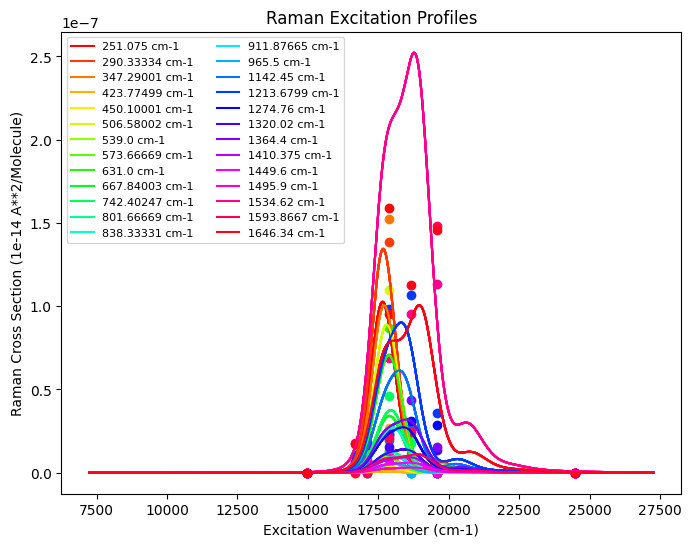

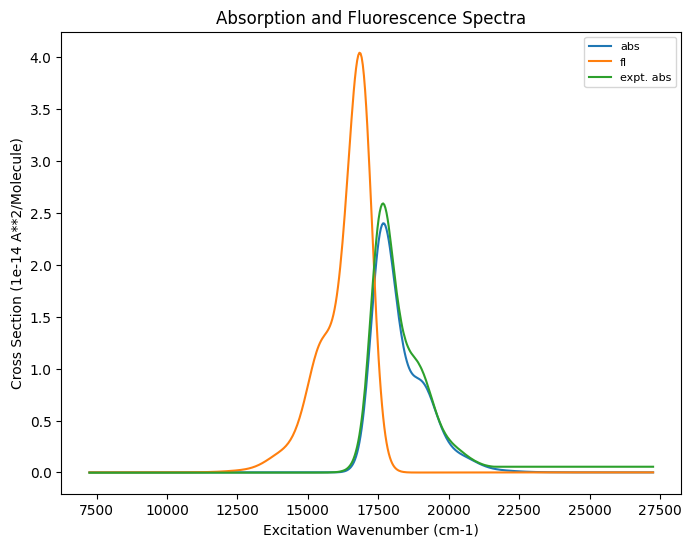

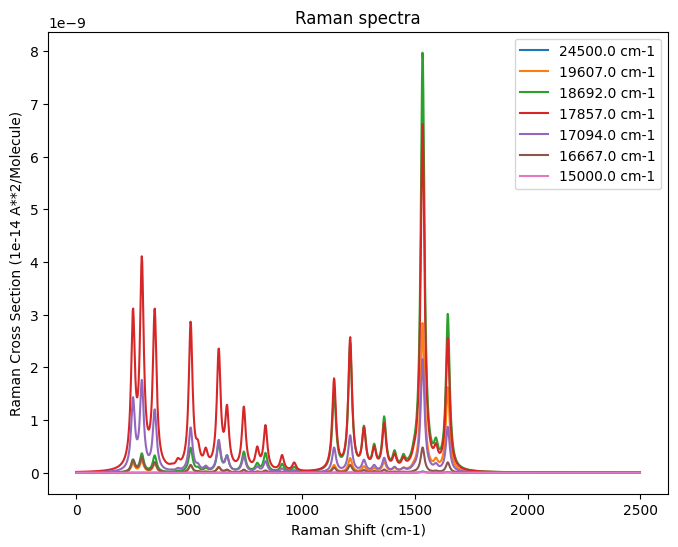

In [4]:
output.plot()

[-4.01531184e-06 -4.16922581e-06 -4.17601367e-06 -4.05012528e-06
 -3.84847853e-06 -3.65339215e-06 -3.54715965e-06 -3.58611081e-06
 -3.78232998e-06 -4.09895189e-06 -4.46079557e-06 -4.77729530e-06
 -4.97074840e-06 -5.00108081e-06 -4.87925133e-06 -4.66483788e-06
 -4.44824694e-06 -4.32284474e-06 -4.35559346e-06 -4.56542033e-06
 -4.91629525e-06 -5.32749526e-06 -5.69816521e-06 -5.93871837e-06
 -5.99931454e-06 -5.88637871e-06 -5.66171305e-06 -5.42413381e-06
 -5.27907275e-06 -5.30548621e-06 -5.53045032e-06 -5.91960484e-06
 -6.38677458e-06 -6.82011755e-06 -7.11688578e-06 -7.21601185e-06
 -7.11820449e-06 -6.88696945e-06 -6.62985406e-06 -6.46543506e-06
 -6.48617333e-06 -6.72876412e-06 -7.16147914e-06 -7.69282912e-06
 -8.19923958e-06 -8.56339264e-06 -8.71135873e-06 -8.63678757e-06
 -8.40427428e-06 -8.13042513e-06 -7.94814910e-06 -7.96509991e-06
 -8.22925485e-06 -8.71262537e-06 -9.31859646e-06 -9.91105161e-06
 -1.03565341e-05 -1.05664107e-05 -1.05257437e-05 -1.02995001e-05
 -1.00136901e-05 -9.81687

c:\Users\Kent\OneDrive - University of Rochester\Documents\Lab\fsrsanalysis\resram_ipynb\resram_core.py:636: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig_raman.show()
c:\Users\Kent\OneDrive - University of Rochester\Documents\Lab\fsrsanalysis\resram_ipynb\resram_core.py:671: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig_profs.show()
c:\Users\Kent\OneDrive - University of Rochester\Documents\Lab\fsrsanalysis\resram_ipynb\resram_core.py:682: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig_abs.show()


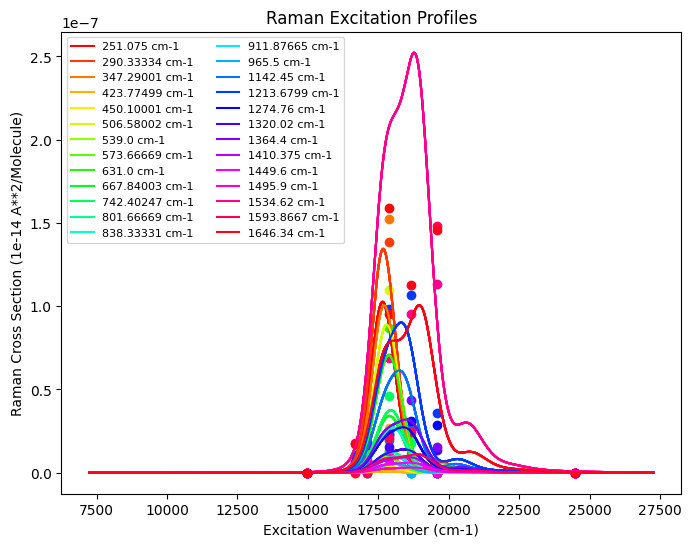

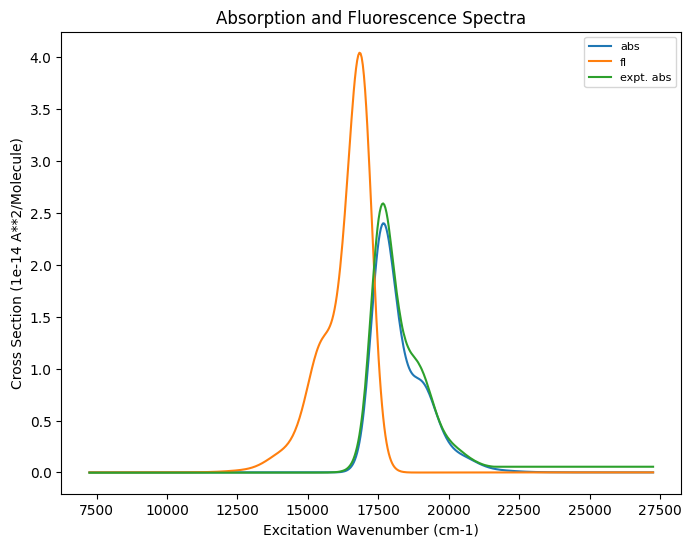

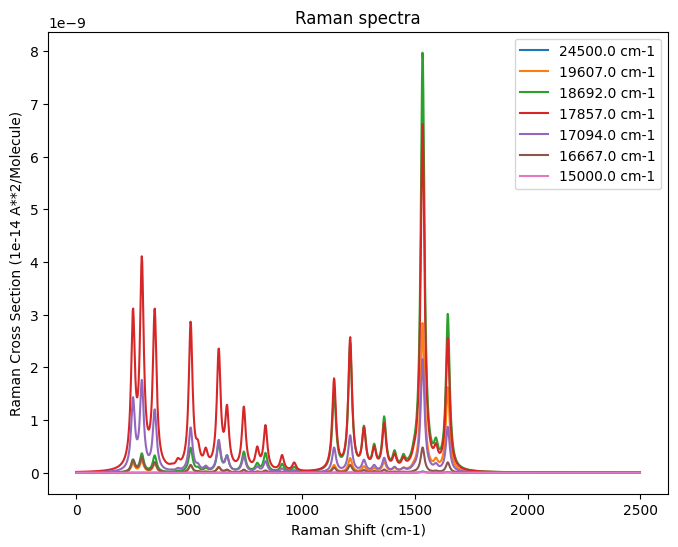

In [2]:
output = resram_data("20250604_13-08-34_data")
print(output.abs)
output.plot()

